# Phase 9 — Attrition Data and EDA

Offline exploratory data analysis for the attrition dataset, entirely within `ml/`. No model
is trained in this notebook — that is Phase 10.

References: PRD **F9.1** (dataset), **F9.2** (EDA breakdowns), **F9.9** (protected-attribute
exclusion). Dataset provenance, licence, and download steps: `data/README.md`.


In [1]:
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

RAW_PATH = Path("../../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# "02_preprocessing.py" starts with a digit, so it can't be a plain `import` target.
_spec = importlib.util.spec_from_file_location("attrition_preprocessing", "02_preprocessing.py")
preprocessing = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(preprocessing)


## Load the raw data

In [2]:
raw = pd.read_csv(RAW_PATH, encoding="utf-8-sig")
print("shape:", raw.shape)
raw.head()


shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data quality: nulls, duplicates, dtypes

In [3]:
print("total missing values:", int(raw.isna().sum().sum()))
print("duplicate rows:", int(raw.duplicated().sum()))
print("duplicate EmployeeNumber:", int(raw["EmployeeNumber"].duplicated().sum()))
raw.dtypes.value_counts()


total missing values: 0
duplicate rows: 0
duplicate EmployeeNumber: 0


int64     26
object     9
Name: count, dtype: int64

No missing values, no duplicate rows, no duplicate `EmployeeNumber` in this dataset — confirmed
by the checks above, not assumed.


## Class balance

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.8388
Yes    0.1612
Name: proportion, dtype: float64


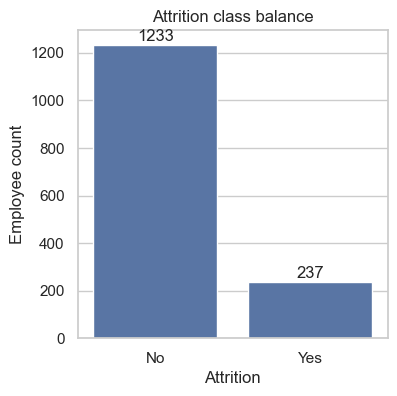

In [4]:
counts = raw["Attrition"].value_counts()
rates = raw["Attrition"].value_counts(normalize=True)
print(counts)
print(rates.round(4))

fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(data=raw, x="Attrition", order=["No", "Yes"], ax=ax)
ax.set_title("Attrition class balance")
ax.set_xlabel("Attrition")
ax.set_ylabel("Employee count")
for i, v in enumerate(counts.reindex(["No", "Yes"])):
    ax.text(i, v + 15, str(v), ha="center")
plt.show()


**Real ratio: 237 Yes / 1,233 No — 16.12% attrition, an ~5.2:1 imbalance.**

Implication for Phase 10 (not solved here): a model that always predicts "No" already scores
~84% accuracy, so accuracy alone would be a meaningless success measure on this data. This is
why F9.3/F10 require the chosen model to be justified on recall/precision, and why F9.4 requires
`class_weight="balanced"` plus a resampling comparison, both reported before/after. Phase 9 only
states the ratio; no imbalance handling happens in this notebook.


## Protected attributes and feature exclusions (PRD F9.9)

In [5]:
feature_table = pd.DataFrame(
    [
        ("Age", "Included (age)", "In locked employees schema; see age note below"),
        ("BusinessTravel", "Included (business_travel)", "In locked employees schema"),
        ("Department", "Included (department)", "In locked employees schema"),
        ("DistanceFromHome", "Included (distance_from_home)", "In locked employees schema"),
        ("EnvironmentSatisfaction", "Included (environment_satisfaction)", "In locked employees schema"),
        ("JobLevel", "Included (job_level)", "In locked employees schema"),
        ("JobSatisfaction", "Included (job_satisfaction)", "In locked employees schema"),
        ("MonthlyIncome", "Included (monthly_income)", "In locked employees schema"),
        ("OverTime", "Included (overtime)", "In locked employees schema"),
        ("PercentSalaryHike", "Included (percent_salary_hike)", "In locked employees schema"),
        ("PerformanceRating", "Included (performance_rating)", "In locked employees schema — see near-constant note below"),
        ("RelationshipSatisfaction", "Included (relationship_satisfaction)", "In locked employees schema"),
        ("StockOptionLevel", "Included (stock_option_level)", "In locked employees schema"),
        ("TotalWorkingYears", "Included (total_working_years)", "In locked employees schema"),
        ("YearsAtCompany", "Included (years_at_company)", "In locked employees schema"),
        ("YearsSinceLastPromotion", "Included (years_since_last_promotion)", "In locked employees schema"),
        ("YearsWithCurrManager", "Included (years_with_curr_manager)", "In locked employees schema"),
        ("Attrition", "Label (attrition)", "Target variable, not a feature"),
        ("Gender", "EXCLUDED", "Protected attribute — PRD F9.9, explicit"),
        ("MaritalStatus", "EXCLUDED", "Protected attribute — PRD F9.9, explicit"),
        ("EmployeeNumber", "Excluded", "Identifier, not a feature (employees.id replaces it)"),
        ("EmployeeCount", "Excluded", "Constant across all rows (verified below), zero variance"),
        ("Over18", "Excluded", "Constant across all rows (verified below), zero variance"),
        ("StandardHours", "Excluded", "Constant across all rows (verified below), zero variance"),
        ("DailyRate", "Excluded", "Not in locked employees schema"),
        ("HourlyRate", "Excluded", "Not in locked employees schema"),
        ("MonthlyRate", "Excluded", "Not in locked employees schema"),
        ("Education", "Excluded", "Not in locked employees schema"),
        ("EducationField", "Excluded", "Not in locked employees schema"),
        ("JobInvolvement", "Excluded", "Not in locked employees schema"),
        ("JobRole", "Excluded", "Not in locked employees schema"),
        ("NumCompaniesWorked", "Excluded", "Not in locked employees schema"),
        ("TrainingTimesLastYear", "Excluded", "Not in locked employees schema"),
        ("WorkLifeBalance", "Excluded", "Not in locked employees schema"),
        ("YearsInCurrentRole", "Excluded", "Not in locked employees schema"),
    ],
    columns=["source_column", "status", "reason"],
)
assert len(feature_table) == 35, "must account for all 35 raw columns"
for c in ("EmployeeCount", "Over18", "StandardHours"):
    assert raw[c].nunique() == 1, f"{c} was assumed constant but isn't"
feature_table


,source_column,status,reason
0,Age,Included (age),In locked employees schema; see age note below
1,BusinessTravel,Included (business_travel),In locked employees schema
2,Department,Included (department),In locked employees schema
3,DistanceFromHome,Included (distance_from_home),In locked employees schema
4,EnvironmentSatisfaction,Included (environment_satisfaction),In locked employees schema
5,JobLevel,Included (job_level),In locked employees schema
6,JobSatisfaction,Included (job_satisfaction),In locked employees schema
7,MonthlyIncome,Included (monthly_income),In locked employees schema
8,OverTime,Included (overtime),In locked employees schema
9,PercentSalaryHike,Included (percent_salary_hike),In locked employees schema


**Age is a considered inclusion, not an oversight.** Raw `Age` is kept as a plain numeric
feature: it is already part of the `employees` table locked at Phase 8 (`Architecture.md`), and
PRD F9.9 names "age **band**" as the excluded quantity, not age itself. **No age-band or
bucketed-age feature is engineered anywhere in this pipeline** — that bucketing is the specific
thing F9.9 calls out, and it does not exist at any stage from this notebook's cleaning through
`02_preprocessing.py`'s serialised transformer. (The "salary band" and "tenure band" groupings
used later in this notebook are chart-only bucketing for visualisation — they are not model
features, and neither is age treated that way anywhere.)

The 17-column feature list above is written down again, verbatim from `02_preprocessing.py`'s
own constants (not retyped by hand), in the **Final feature list** section near the end of this
notebook — so "matches the `employees` table" is provable by construction, not just asserted
here.


## Outliers

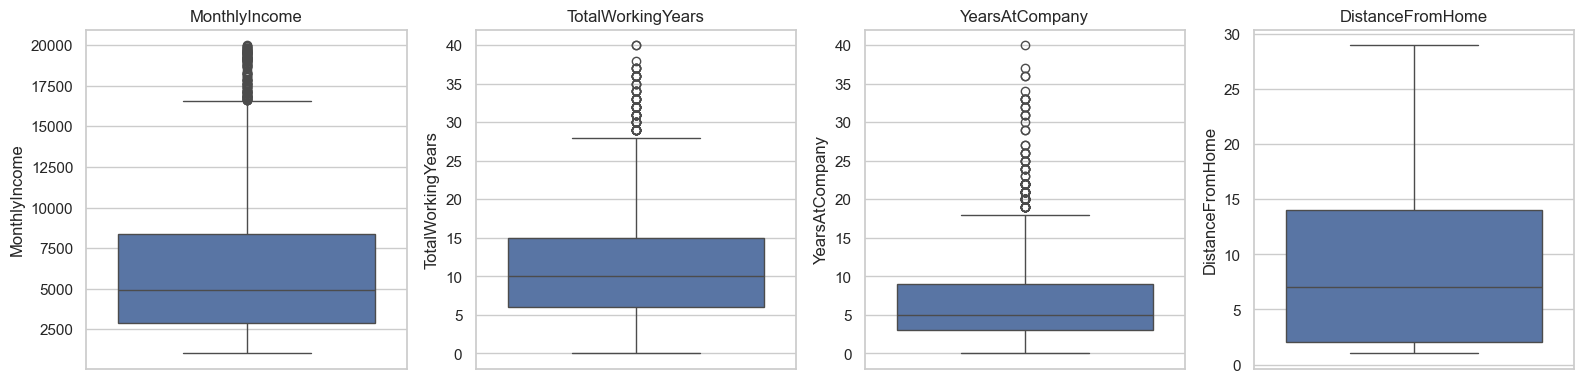

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
outlier_cols = ["MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "DistanceFromHome"]
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=raw[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Outliers are visible above (e.g. long-tenure and high-income employees) and are deliberately
not clipped or removed in this phase.** This is a stated decision, not an omission: no model
exists yet to judge whether a given outlier is a genuine high-tenure/high-earner case worth
keeping or a data-quality defect worth capping, and premature clipping could remove exactly the
signal a later model needs. Outlier handling, if any, is a Phase 10 modelling-time decision.


## `performance_rating`: a near-constant feature

PerformanceRating
3    1244
4     226
Name: count, dtype: int64


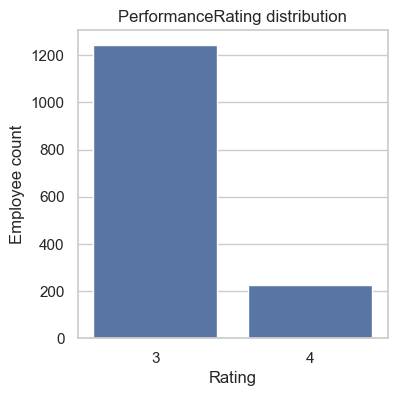

In [7]:
rating_counts = raw["PerformanceRating"].value_counts().sort_index()
print(rating_counts)
rating_counts.index = rating_counts.index.astype(str)

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=ax)
ax.set_title("PerformanceRating distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Employee count")
plt.show()


`performance_rating` takes only 2 distinct values across all 1,470 employees in this dataset —
confirmed above, not a footnote. A near-constant feature contributes almost no separating signal
and can mislead a feature-importance reading in Phase 10, which then feeds the per-prediction
explanations a user sees in Phase 11. `Phases.md`'s Phase 10 build list now carries an explicit
line for this: check its feature importance is not misleading before surfacing it as a
contributing factor.


## Attrition rate breakdowns (PRD F9.2) — the six required visualisations

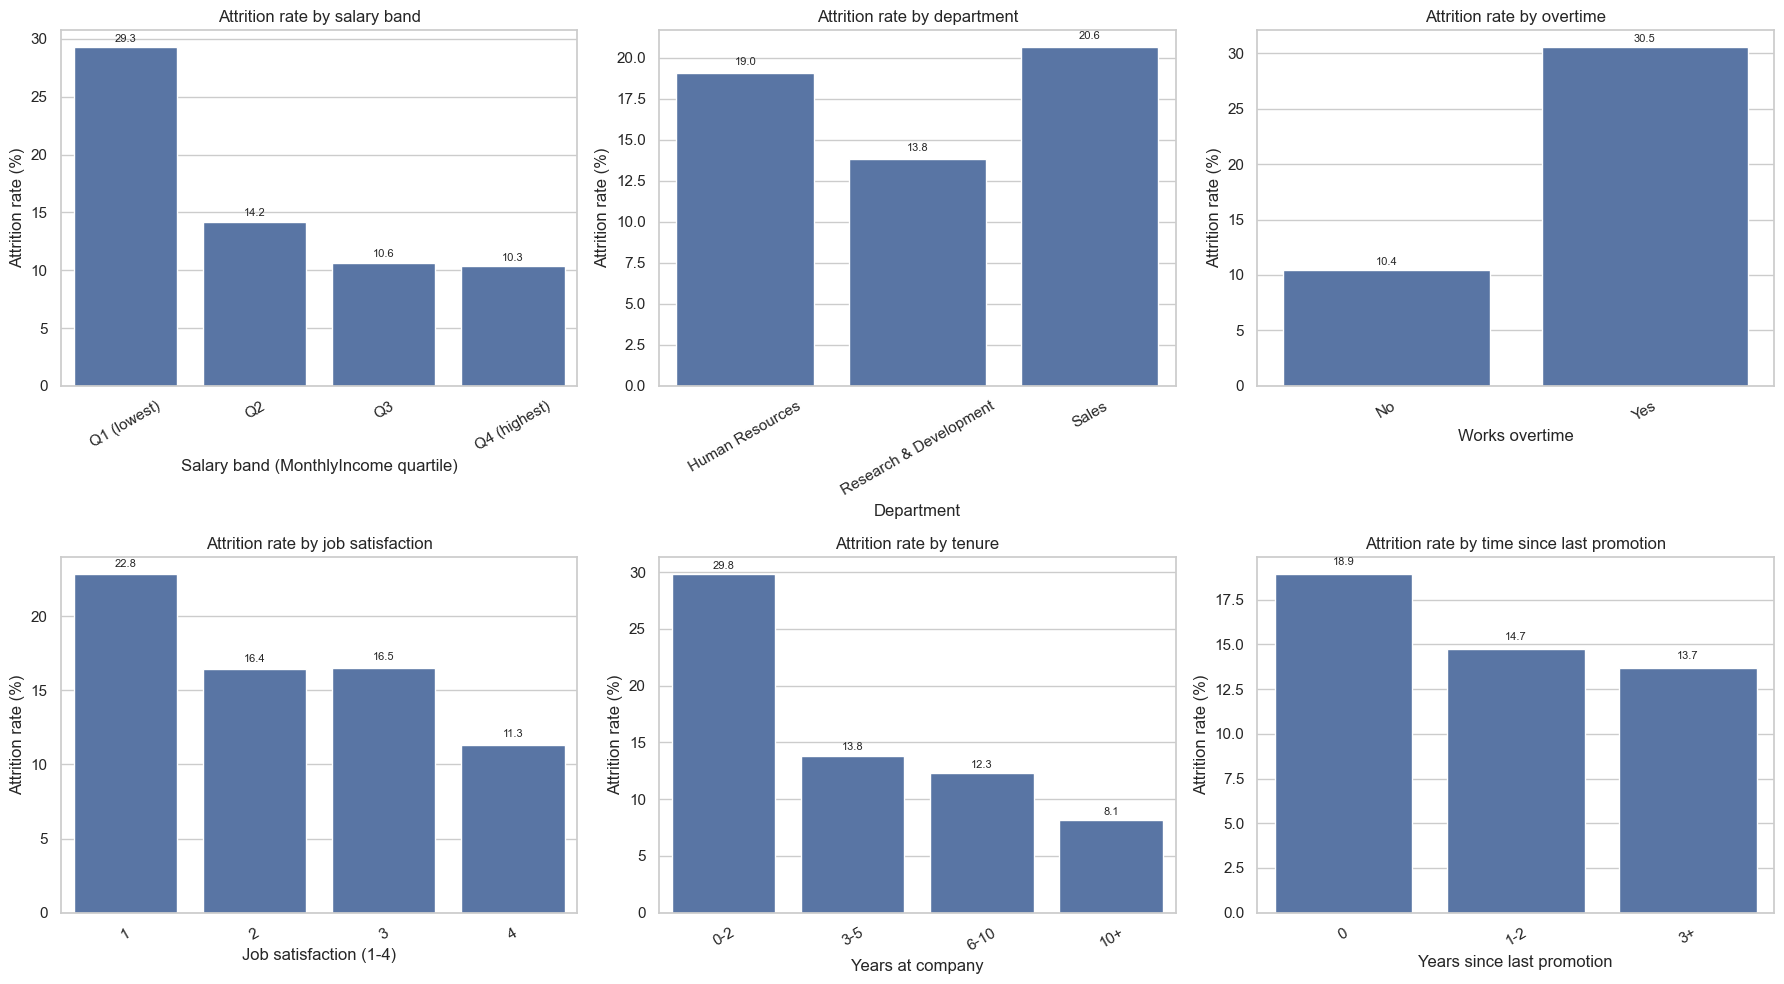

--- salary_band ---
salary_band
Q1 (lowest)     29.27
Q2              14.21
Q3              10.63
Q4 (highest)    10.33
Name: attrition_flag, dtype: float64
--- Department ---
Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: attrition_flag, dtype: float64
--- OverTime ---
OverTime
No     10.44
Yes    30.53
Name: attrition_flag, dtype: float64
--- JobSatisfaction ---
JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: attrition_flag, dtype: float64
--- tenure_band ---
tenure_band
0-2     29.82
3-5     13.82
6-10    12.28
10+      8.13
Name: attrition_flag, dtype: float64
--- promotion_gap_band ---
promotion_gap_band
0      18.93
1-2    14.73
3+     13.67
Name: attrition_flag, dtype: float64


In [8]:
df = raw.copy()
df["salary_band"] = pd.qcut(df["MonthlyIncome"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
df["tenure_band"] = pd.cut(
    df["YearsAtCompany"], bins=[-1, 2, 5, 10, 100], labels=["0-2", "3-5", "6-10", "10+"]
)
df["promotion_gap_band"] = pd.cut(
    df["YearsSinceLastPromotion"], bins=[-1, 0, 2, 100], labels=["0", "1-2", "3+"]
)
df["attrition_flag"] = (df["Attrition"] == "Yes").astype(int)

breakdowns = [
    ("salary_band", "Attrition rate by salary band", "Salary band (MonthlyIncome quartile)"),
    ("Department", "Attrition rate by department", "Department"),
    ("OverTime", "Attrition rate by overtime", "Works overtime"),
    ("JobSatisfaction", "Attrition rate by job satisfaction", "Job satisfaction (1-4)"),
    ("tenure_band", "Attrition rate by tenure", "Years at company"),
    ("promotion_gap_band", "Attrition rate by time since last promotion", "Years since last promotion"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
rates_by_group = {}
for ax, (col, title, xlabel) in zip(axes.flat, breakdowns):
    rate = df.groupby(col, observed=True)["attrition_flag"].mean().mul(100)
    rates_by_group[col] = rate
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Attrition rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

for col, rate in rates_by_group.items():
    print(f"--- {col} ---")
    print(rate.round(2))


Six labelled charts above; real rates from this run, one line each:

1. **Salary band** — a clear downward step: Q1 (lowest) 29.3% attrition, Q2 14.2%, Q3 10.6%, Q4
   (highest) 10.3%. Almost all of the gap is between the bottom quartile and everyone else.
2. **Department** — Sales 20.6%, Human Resources 19.1%, Research & Development 13.8%. HR's
   figure is the noisiest of the three (smallest department by headcount) despite sitting close
   to Sales.
3. **Overtime** — 30.5% attrition among employees who work overtime vs. 10.4% among those who
   don't — the largest gap of the six breakdowns.
4. **Job satisfaction** — mostly monotonic: level 1 22.8%, level 2 16.4%, level 3 16.5% (a small
   non-monotonic bump), level 4 11.3%.
5. **Tenure** — highest among the newest employees and falls steadily: 0-2 years 29.8%, 3-5
   years 13.8%, 6-10 years 12.3%, 10+ years 8.1%.
6. **Time since last promotion** — the real result runs **opposite** to a naive
   "stagnation causes attrition" story: employees at 0 years since their last promotion show
   the *highest* attrition at 18.9%, falling to 14.7% at 1-2 years and 13.7% at 3+ years. As
   flagged above, tenure and years-since-promotion are correlated (you cannot be 5 years past a
   promotion with 2 years of tenure) — **this is checked directly, not left as an open
   question, in "Tenure-controlled check" below.**


## Tenure-controlled check: is the promotion-gap effect real, or confounded by tenure?

The 18.9% headline for `YearsSinceLastPromotion == 0` above is unconditioned — it does not hold tenure fixed. Since `YearsSinceLastPromotion` cannot exceed `YearsAtCompany` by construction, a brand-new hire is *definitionally* at 0 years since their last promotion (they've never been promoted), so the 0-years group is mechanically loaded with new hires — exactly the group already shown to have the highest attrition on its own, independent of promotion history. This checks whether the promotion-gap effect survives once tenure is held fixed.

In [9]:
df["promo_group"] = df["YearsSinceLastPromotion"].apply(lambda y: "0 (never promoted here)" if y == 0 else ">0")
# Exact bands requested for this check: 0-2 / 3-5 / 6+ (distinct from the 0-2/3-5/6-10/10+
# bands used for the six-visualisation grid above).
df["tenure_band_3"] = pd.cut(df["YearsAtCompany"], bins=[-1, 2, 5, 100], labels=["0-2", "3-5", "6+"])

overall = df.groupby("promo_group")["attrition_flag"].agg(["count", "mean"])
overall["rate_pct"] = (overall["mean"] * 100).round(2)
print("Unconditioned (matches the breakdown above):")
print(overall[["count", "rate_pct"]])
print()

within = df.groupby(["tenure_band_3", "promo_group"], observed=True)["attrition_flag"].agg(["count", "sum", "mean"])
within["rate_pct"] = (within["mean"] * 100).round(2)
within = within.rename(columns={"sum": "attritions"})
print("Within tenure bands (0-2 / 3-5 / 6+):")
print(within[["count", "attritions", "rate_pct"]])
print()

overlap = df[(df["YearsSinceLastPromotion"] == 0) & (df["tenure_band_3"] == "0-2")]
zero_promo_total = (df["YearsSinceLastPromotion"] == 0).sum()
print(f"Structural overlap: {len(overlap)}/{zero_promo_total} "
      f"({len(overlap) / zero_promo_total * 100:.1f}%) of everyone at 0-years-since-promotion "
      "is also in the 0-2-year tenure band.")

Unconditioned (matches the breakdown above):
                         count  rate_pct
promo_group                             
0 (never promoted here)    581     18.93
>0                         889     14.29

Within tenure bands (0-2 / 3-5 / 6+):
                                       count  attritions  rate_pct
tenure_band_3 promo_group                                         
0-2           0 (never promoted here)    216          70     32.41
              >0                         126          32     25.40
3-5           0 (never promoted here)    197          26     13.20
              >0                         237          34     14.35
6+            0 (never promoted here)    168          14      8.33
              >0                         526          61     11.60

Structural overlap: 216/581 (37.2%) of everyone at 0-years-since-promotion is also in the 0-2-year tenure band.


**Interpretation constraint:** `years_since_last_promotion` must not be read as a standalone "promotion stagnation" signal. Its pooled 18.9% attrition figure is strongly confounded by tenure — the association **reverses** in the 3-5y (13.2% vs 14.4%) and 6+y (8.3% vs 11.6%) bands, and survives only in the 0-2y band (32.4% vs 25.4%, n=126 in the `>0` comparison cell — smaller than the other cells, treat this surviving direction as provisional, not settled).

**The variable carries opposite meanings at the two ends of the tenure range.** At 0-2y tenure, `years_since_last_promotion == 0` mostly encodes "never promoted, newly hired" — structurally guaranteed, since 37.2% of the entire 0-years-since-promotion group (216 of 581) is also in the 0-2-year tenure band, and you cannot be years past a promotion you've never had. At 6+y tenure, the same value instead means "recently promoted" — a positive signal, consistent with that group's lower attrition. **Feature-importance output in Phase 10/11 must be interpreted alongside tenure, never alone.**

This conclusion is kept descriptive, not causal: this dataset is synthetic (IBM-generated), so a stratum reversal like this may be an artifact of how the data was generated rather than a real workplace mechanism.

## Final feature list

In [10]:
print(f"{len(preprocessing.FEATURE_COLUMNS)} features, from ml/attrition/02_preprocessing.py:")
for c in preprocessing.FEATURE_COLUMNS:
    print(" -", c)


17 features, from ml/attrition/02_preprocessing.py:
 - age
 - distance_from_home
 - monthly_income
 - percent_salary_hike
 - total_working_years
 - years_at_company
 - years_since_last_promotion
 - years_with_curr_manager
 - job_level
 - job_satisfaction
 - environment_satisfaction
 - relationship_satisfaction
 - performance_rating
 - stock_option_level
 - department
 - business_travel
 - overtime


## Preprocessing pipeline: fit, save, and verify a fresh-process round-trip

In [11]:
X, y = preprocessing.load_and_clean(RAW_PATH)
print("X shape:", X.shape, " y shape:", y.shape)
X.head()


X shape: (1470, 17)  y shape: (1470,)


,age,distance_from_home,monthly_income,percent_salary_hike,total_working_years,years_at_company,years_since_last_promotion,years_with_curr_manager,job_level,job_satisfaction,environment_satisfaction,relationship_satisfaction,performance_rating,stock_option_level,department,business_travel,overtime
0,41,1,5993,11,8,6,0,5,2,4,2,1,3,0,Sales,Travel_Rarely,1
1,49,8,5130,23,10,10,1,7,2,2,3,4,4,1,Research & Development,Travel_Frequently,0
2,37,2,2090,15,7,0,0,0,1,3,4,2,3,0,Research & Development,Travel_Rarely,1
3,33,3,2909,11,8,8,3,0,1,3,4,3,3,0,Research & Development,Travel_Frequently,1
4,27,2,3468,12,6,2,2,2,1,2,1,4,3,1,Research & Development,Travel_Rarely,0


The pipeline is fit and saved, then reloaded **in two genuinely separate Python interpreter
processes** (via `subprocess`, not just re-run in this notebook's own kernel) to prove
serialisation round-trips with identical output — process A fits and saves the artifact plus a
reference transform of a fixed row slice; process B loads *only* the saved `.joblib` file from
disk, with no memory shared with process A, transforms the same slice, and the two arrays are
compared with `np.array_equal` (exact equality, not a tolerance — nothing in this pipeline is
stochastic).


In [12]:
import subprocess
import sys

ARTIFACT_PATH = "artifacts/preprocessor.joblib"
REFERENCE_PATH = "artifacts/_roundtrip_reference.npy"

fit_script = f'''
import importlib.util
spec = importlib.util.spec_from_file_location("attrition_preprocessing", "02_preprocessing.py")
m = importlib.util.module_from_spec(spec)
spec.loader.exec_module(m)
import numpy as np
X, y = m.load_and_clean("{RAW_PATH.as_posix()}")
pipeline = m.fit_and_save(X, "{ARTIFACT_PATH}")
ref = pipeline.transform(X.iloc[:20])
np.save("{REFERENCE_PATH}", ref)
print("process A: fit + saved, reference shape", ref.shape)
'''

verify_script = f'''
import importlib.util
spec = importlib.util.spec_from_file_location("attrition_preprocessing", "02_preprocessing.py")
m = importlib.util.module_from_spec(spec)
spec.loader.exec_module(m)
import numpy as np
X, y = m.load_and_clean("{RAW_PATH.as_posix()}")
pipeline = m.load_pipeline("{ARTIFACT_PATH}")
reloaded = pipeline.transform(X.iloc[:20])
reference = np.load("{REFERENCE_PATH}")
identical = bool(np.array_equal(reloaded, reference))
print("process B: reloaded shape", reloaded.shape, "identical to reference:", identical)
assert identical, "round-trip mismatch"
'''

result_a = subprocess.run([sys.executable, "-c", fit_script], capture_output=True, text=True, cwd=".")
print(result_a.stdout)
if result_a.returncode != 0:
    print(result_a.stderr)
assert result_a.returncode == 0, "process A failed"

result_b = subprocess.run([sys.executable, "-c", verify_script], capture_output=True, text=True, cwd=".")
print(result_b.stdout)
if result_b.returncode != 0:
    print(result_b.stderr)
assert result_b.returncode == 0, "process B failed"

Path(REFERENCE_PATH).unlink(missing_ok=True)
print("ROUND-TRIP VERIFIED: the serialised pipeline, reloaded in a fresh process with no shared")
print("memory, reproduces exactly the same output as the original fit. See artifacts/preprocessor.joblib.")


process A: fit + saved, reference shape (20, 21)



process B: reloaded shape (20, 21) identical to reference: True

ROUND-TRIP VERIFIED: the serialised pipeline, reloaded in a fresh process with no shared
memory, reproduces exactly the same output as the original fit. See artifacts/preprocessor.joblib.
